# Bias Detection & Fairness Analysis

**Owner:** Othmane Chadi (70269) – Data Scientist 

**Course:** 2606 Data Ecosystems and Governance in Organizations

This notebook fulfills the **Bias Detection & Fairness** component of the NovaCred Credit Application Governance Audit. It is organized to align with the assignment rubric: **(1)** Disparate Impact (DI) and four-fifths rule for gender, **(2)** bias interpretation, **(3)** age-based bias, **(4)** proxy discrimination analysis, **(5)** interaction effects, **(6)** visualizations, and **(7)** statistical/fairness methods. The analysis uses the cleaned dataset from `01-data-quality.ipynb`.

## Table of Contents

| Section | Description |
|---------|-------------|
| [1. Setup and Data Loading](#1-setup-and-data-loading) | Imports, load cleaned data, prepare outcome and gender columns |
| [2. Gender Disparate Impact](#2-gender-disparate-impact) | Approval rates by gender, DI ratio, four-fifths rule (DI < 0.8), chi-square test |
| [3. Age-Based Patterns](#3-age-based-patterns) | Age from date of birth, approval rates by age group |
| [4. Proxy Variables](#4-proxy-variables) | [4.1 Geography](#4-1-geography), [4.2 Financial](#4-2-financial), [4.3 Spending](#4-3-spending) - proxy detection |
| [5. Interaction Effects](#5-interaction-effects) | Gender × age, income, zip/region |
| [6. Fairness](#6-fairness) | Conditional fairness, pricing, fairness metrics |
| [7. Synthesis](#7-synthesis) | Bias risk matrix, types of bias, summary and recommendations |

<a id='1-setup-and-data-loading'></a>

# 1. Setup and Data Loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import ast

DATA_PATH = Path("../data/credit_applications_clean_final.csv")

# Column names (used across sections)
GENDER_COL = "applicant_info.gender"
OUTCOME_COL = "decision.loan_approved"
# Disparate impact: four-fifths rule threshold
DI_THRESHOLD = 0.80
# Colour encoding for gender (consistent across plots)
COLOUR_F = "#e05c5c"   # Female
COLOUR_M = "#4a90d9"   # Male
COLOUR_NEU = "#2c3e50"   # Neutral: age groups, regions (dark blue)
# Cleaner plots for the notebook
sns.set_theme(style="whitegrid", font_scale=1.1)

In [2]:
# Load cleaned dataset; df is the main dataframe used throughout the notebook.
df = pd.read_csv(DATA_PATH)
df["applicant_info.date_of_birth"] = pd.to_datetime(df["applicant_info.date_of_birth"], errors="coerce")
print(f"Dataset : {DATA_PATH}")
print(f"Records : {len(df)}")
print(f"Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)

Dataset : ../data/credit_applications_clean_final.csv
Records : 498
Shape   : 498 rows × 20 columns


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15 00:00:00+00:00,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212.0,False,algorithm_risk_score,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915.0,False,algorithm_risk_score,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909.0,True,NaN,vacation,3.7,59000.0,NaN


<a id='2-gender-disparate-impact'></a>

## 2. Gender Disparate Impact

Gender is recorded as Male/Female; we restrict to these two values for the analysis (excluded count in the output below).

**DI = (approval rate of unprivileged group) / (approval rate of privileged group)**  
A value **below 0.8** (four-fifths rule) indicates potential disparate impact. The 0.8 (four-fifths) threshold comes from the **EEOC Uniform Guidelines on Employee Selection Procedures**.

In [3]:
gender_col = GENDER_COL
outcome_col = OUTCOME_COL

valid = df[df[gender_col].isin(["Male", "Female"])].copy()
n_excluded = len(df) - len(valid)
rates = valid.groupby(gender_col)[outcome_col].agg(["mean", "sum", "count"])
rates.columns = ["approval_rate", "approved", "total"]
display(rates)

# Privileged = Male, Unprivileged = Female (typical convention for credit; adjust if needed)
rate_privileged = rates.loc["Male", "approval_rate"]
rate_unprivileged = rates.loc["Female", "approval_rate"]
# DI ratio = unprivileged approval rate / privileged approval rate (four-fifths rule: threshold 0.8)
di_ratio = rate_unprivileged / rate_privileged if rate_privileged > 0 else float("nan")

print(f"Records used (Male/Female): {len(valid)}; {n_excluded} excluded.")
print(f"Approval rate (Male)   : {rate_privileged:.2%}")
print(f"Approval rate (Female) : {rate_unprivileged:.2%}")
print(f"Disparate impact ratio : {di_ratio:.3f}")
print(f"Four-fifths rule (DI < {DI_THRESHOLD}): {'Potential disparate impact' if di_ratio < DI_THRESHOLD else 'Within threshold'}")

,approval_rate,approved,total
applicant_info.gender,,,
Female,0.508000,127,250
Male,0.662602,163,246


Records used (Male/Female): 496; 2 excluded.
Approval rate (Male)   : 66.26%
Approval rate (Female) : 50.80%
Disparate impact ratio : 0.767
Four-fifths rule (DI < 0.8): Potential disparate impact


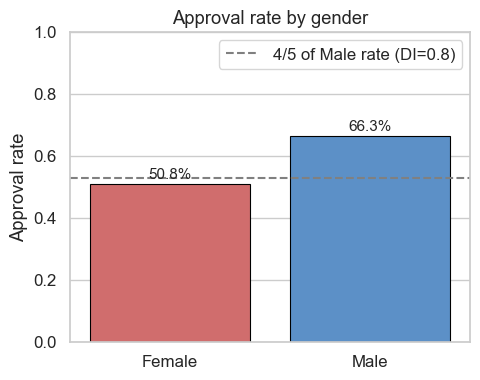

In [4]:
# Visualization: approval rate by gender (four-fifths threshold)
fig, ax = plt.subplots(figsize=(5, 4))
plot_df = rates.reset_index()
sns.barplot(data=plot_df, x=gender_col, y="approval_rate", palette=[COLOUR_F, COLOUR_M], ax=ax, edgecolor="black", linewidth=0.8)
ax.axhline(DI_THRESHOLD * rate_privileged, color="gray", linestyle="--", linewidth=1.5, label=f"4/5 of Male rate (DI={DI_THRESHOLD})")
ax.set_title("Approval rate by gender")
ax.set_ylabel("Approval rate")
ax.set_xlabel("")
ax.set_ylim(0, 1)
for i, row in plot_df.iterrows():
    ax.text(i, row["approval_rate"] + 0.02, f"{row['approval_rate']:.1%}", ha="center", fontsize=11)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Statistical test:** Chi-square test for independence (gender vs approval). A low p-value suggests the association is unlikely due to chance.

In [5]:
# Chi-square test for independence: gender vs approval
from scipy.stats import chi2_contingency
cont_table = pd.crosstab(valid[gender_col], valid[outcome_col])
chi2, p_value, dof, expected = chi2_contingency(cont_table)
print(f"Chi-square statistic : {chi2:.4f}")
print(f"p-value            : {p_value:.4f}")
print(f"Conclusion: {'Association is statistically significant (reject independence)' if p_value < 0.05 else 'Cannot reject independence at 5% level'}")

Chi-square statistic : 11.5761
p-value            : 0.0007
Conclusion: Association is statistically significant (reject independence)


**Interpretation (1)**  
Because 0.767 < 0.8, the four-fifths rule is violated, indicating potential disparate impact on female applicants. The disparate impact ratio of about 0.77 is below the 0.8 threshold: their approval rate is meaningfully lower than males’ (about 51% vs 66%). The chi-square test (p ≈ 0.0007) confirms the association is statistically significant. The team should flag this for governance and consider model or data remediation (e.g. fairness constraints, feature review, or further analysis of drivers).

<a id='3-age-based-patterns'></a>

## 3. Age-Based Patterns

Derive age from date of birth and check approval rates by age group (age as a protected/sensitive dimension).

**Why these age groups?** The bins 18–30, 31–40, 41–50, 51–65, and 65+ are commonly used in lending and fairness audits: **18** is the typical minimum age for legal contracts/credit; **30** separates young from prime working age; **40** and **50** are standard mid/older segments; **65** is the usual retirement-age threshold, so **65+** is a protected or sensitive group. The upper bound 100 simply caps the last bin. This choice aligns with regulatory and fair-lending practice and keeps group sizes interpretable.

In [6]:
ref_date = pd.Timestamp("2024-01-01")
# Derive age in years from date of birth (365.25 for leap-year adjustment)
df["age"] = ((ref_date - df["applicant_info.date_of_birth"]).dt.days / 365.25).astype(float)
age_valid = df[df["age"].between(18, 100)].copy()
age_valid["age_group"] = pd.cut(age_valid["age"], bins=[18, 30, 40, 50, 65, 100], labels=["18-30", "31-40", "41-50", "51-65", "65+"])
by_age = age_valid.groupby("age_group")[outcome_col].agg(["mean", "count"]).round(3)
by_age.columns = ["approval_rate", "count"]
display(by_age)
print("\nConsider whether approval rates differ materially across age groups (age-based bias).")

,approval_rate,count
age_group,,
18-30,0.414,116
31-40,0.625,168
41-50,0.688,125
51-65,0.573,82
65+,1.000,3



Consider whether approval rates differ materially across age groups (age-based bias).


In [7]:
# Chi-square test: age_group vs approval (independence)
from scipy.stats import chi2_contingency
cont_age = pd.crosstab(age_valid["age_group"], age_valid[outcome_col])
chi2_age, p_age, dof_age, expected_age = chi2_contingency(cont_age)
print(f"Chi-square (age_group vs approval): {chi2_age:.4f}, p-value: {p_age:.4f}")
if p_age < 0.05:
    print("Conclusion: Approval and age group are not independent at α = 0.05.")
else:
    print("Conclusion: Cannot reject independence between approval and age group at α = 0.05.")

# Optional: age-based DI (e.g. 18-30 vs 41-50)
if "18-30" in by_age.index and "41-50" in by_age.index:
    r_young = by_age.loc["18-30", "approval_rate"]
    r_mid = by_age.loc["41-50", "approval_rate"]
    di_age = r_young / r_mid if r_mid > 0 else float("nan")
    print(f"\nAge-based DI (18-30 vs 41-50): {di_age:.3f} (18-30 rate / 41-50 rate).")
    if di_age < DI_THRESHOLD:
        print("Interpretation: Approval rate for 18-30 is below four-fifths of 41-50, suggesting potential disparate impact on younger applicants.")

Chi-square (age_group vs approval): 22.7508, p-value: 0.0001
Conclusion: Approval and age group are not independent at α = 0.05.

Age-based DI (18-30 vs 41-50): 0.602 (18-30 rate / 41-50 rate).
Interpretation: Approval rate for 18-30 is below four-fifths of 41-50, suggesting potential disparate impact on younger applicants.


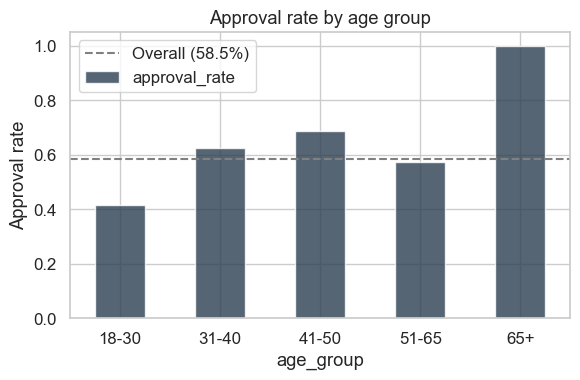

In [8]:
# Visualization: approval rate by age group
fig, ax = plt.subplots(figsize=(6, 4))
by_age["approval_rate"].plot(kind="bar", ax=ax, color=COLOUR_NEU, alpha=0.8)
overall_rate = age_valid[outcome_col].mean()
ax.axhline(overall_rate, color="gray", linestyle="--", linewidth=1.5, label=f"Overall ({overall_rate:.1%})")
ax.legend()
ax.set_title("Approval rate by age group")
ax.set_ylabel("Approval rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Interpretation (3)**  
Approval rates vary by age: lowest for 18–30 (about 41%), higher for 31–40 and 41–50 (about 63–69%), and lower again for 51–65 (about 57%). The 65+ group has very few applicants. This pattern suggests age may be associated with outcomes; the team should confirm whether this reflects risk-relevant factors (e.g. income, tenure) or possible age-related bias, and document the rationale for any age-related policy.

<a id='4-proxy-variables'></a>

## 4. Proxy Variables for Protected Attributes

We test **proxy discrimination** with two conditions: **(1)** the variable is associated with a protected attribute (gender); **(2)** the variable predicts approval **after** controlling for gender and risk factors. If both are met, we treat it as proxy risk. We apply this to **(4.1)** geography (ZIP/region), **(4.2)** financial variables (heatmap and key stats), and **(4.3)** spending behaviour.


<a id='4-1-geography'></a>

### 4.1 Geographical (ZIP/region)

We test whether **ZIP/region** acts as a proxy for gender. **Condition 1:** ZIP must be associated with gender (chi-square). **Condition 2:** ZIP must predict approval after controlling for gender and financial risk (logistic regression). Region aggregates use **Male/Female applicants only** (same scope as Section 2). For the regression we restrict to the two dominant regions (100 and 902) for a clean test.


In [9]:
# Build region aggregates once (Male/Female only); use zip prefix when exact zip is too sparse
zip_col = "applicant_info.zip_code"
df_zip = valid[valid[zip_col].notna()].copy()
df_zip["zip_prefix"] = df_zip[zip_col].astype(int).astype(str).str[:3]
by_region = df_zip.groupby("zip_prefix").agg(
    approval_rate=(outcome_col, "mean"),
    count=(outcome_col, "count"),
    pct_female=(gender_col, lambda s: (s == "Female").mean())
).round(3)
by_region = by_region[by_region["count"] >= 5].sort_values("approval_rate")
print("Region aggregates (Male/Female applicants only, zip prefix, >=5 per region):")
display(by_region)
if len(by_region) < 3:
    print("Too few regions for correlation; plot only.")


Region aggregates (Male/Female applicants only, zip prefix, >=5 per region):


,approval_rate,count,pct_female
zip_prefix,,,
902,0.520,229,0.934
300,0.556,18,0.444
100,0.647,249,0.112


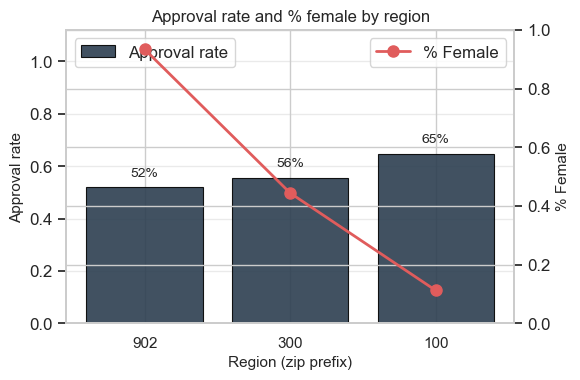

In [10]:
# Approval rate and % female by region (uses by_region from previous cell)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(by_region))
ax.bar(x, by_region["approval_rate"], color=COLOUR_NEU, alpha=0.9, edgecolor="black", linewidth=0.8, label="Approval rate")
for i, val in enumerate(by_region["approval_rate"]):
    ax.text(i, val + 0.03, f"{val:.0%}", ha="center", va="bottom", fontsize=10, fontweight="medium")
ax.set_xticks(x)
ax.set_xticklabels(by_region.index, fontsize=11)
ax.set_ylabel("Approval rate", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_xlabel("Region (zip prefix)", fontsize=11)
ax.set_title("Approval rate and % female by region", fontsize=12, fontweight="medium")
ax2 = ax.twinx()
ax2.plot(x, by_region["pct_female"], color=COLOUR_F, marker="o", linewidth=2, markersize=8, label="% Female")
ax2.set_ylabel("% Female", fontsize=11)
ax2.set_ylim(0, 1)
ax2.legend(loc="upper right", frameon=True)
ax.legend(loc="upper left", frameon=True)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


In [11]:
# Two-condition proxy test: ZIP/region
from scipy.stats import chi2_contingency

zip_col = "applicant_info.zip_code"
# Restrict to two dominant regions for a clean binary test
df_zip_12 = df_zip[df_zip["zip_prefix"].isin(["100", "902"])].copy()
df_zip_12["zip_100"] = (df_zip_12["zip_prefix"] == "100").astype(int)

# Condition 1: ZIP ↔ gender (chi-square)
ct_zip_gender = pd.crosstab(df_zip_12["zip_prefix"], df_zip_12[gender_col], rownames=["ZIP-3"], colnames=["Gender"])
chi2_zg, p_zg, dof_zg, _ = chi2_contingency(ct_zip_gender)
print("Condition 1: ZIP vs Gender:")
print(ct_zip_gender.to_string())
print(f"  χ² = {chi2_zg:.2f}, df = {dof_zg}, p = {p_zg:.2e}")
print(f"  Condition 1 met: {'YES: ZIP is strongly associated with gender' if p_zg < 0.05 else 'NO'}")
print()

# Condition 2: ZIP → approval after controls (logistic regression)
# Ensure age exists (from Section 3)
if "age" not in df_zip_12.columns:
    ref_date = pd.Timestamp("2024-01-01")
    df_zip_12["age"] = ((ref_date - pd.to_datetime(df_zip_12["applicant_info.date_of_birth"])).dt.days / 365.25).astype(float)
inc_col = "financials.annual_income"
dti_col = "financials.debt_to_income"
hist_col = "financials.credit_history_months"
sav_col = "financials.savings_balance"
df_zip_12["gender_bin"] = (df_zip_12[gender_col] == "Male").astype(int)
df_zip_12["approved"] = df_zip_12[outcome_col].astype(int)
feat_zip = ["gender_bin", "age", inc_col, dti_col, hist_col, sav_col, "zip_100"]
df_zip_cln = df_zip_12[feat_zip + ["approved"]].dropna()
Xz = sm.add_constant(df_zip_cln[feat_zip])
yz = df_zip_cln["approved"]
logit_z = sm.Logit(yz, Xz).fit(disp=0)
coef_zip = logit_z.params["zip_100"]
p_zip = logit_z.pvalues["zip_100"]
print("Condition 2: ZIP effect on approval (controlling for gender + financial risk):")
print(f"  zip_100 coefficient: {coef_zip:.4f}")
print(f"  Odds ratio:          {np.exp(coef_zip):.4f}")
print(f"  p-value:             {p_zip:.4f}")
print(f"  Condition 2 met: {'YES: ZIP predicts approval after controls' if p_zip < 0.05 else 'NO'}")
print()
both_zip = p_zg < 0.05 and p_zip < 0.05
print(f"PROXY VERDICT (ZIP): {'Both conditions met: proxy risk confirmed' if both_zip else 'Not fully established'}")


Condition 1: ZIP vs Gender:
Gender  Female  Male
ZIP-3               
100         28   221
902        214    15
  χ² = 319.22, df = 1, p = 2.14e-71
  Condition 1 met: YES: ZIP is strongly associated with gender

Condition 2: ZIP effect on approval (controlling for gender + financial risk):
  zip_100 coefficient: 0.0786
  Odds ratio:          1.0817
  p-value:             0.8167
  Condition 2 met: NO

PROXY VERDICT (ZIP): Not fully established


**Interpretation (4.1)**  
**Condition 1** (ZIP ↔ gender): A significant chi-square indicates that region is associated with gender in the data. **Condition 2** (ZIP → approval after controls): A significant coefficient for *zip_100* in the logistic regression means region predicts approval even after controlling for gender and financial risk. If **both** conditions are met, the verdict is **proxy risk confirmed**: a model using region could indirectly discriminate by gender; consider excluding region from the model or applying fairness constraints. If the verdict is *Not fully established*, there is insufficient evidence for proxy discrimination on region in this sample.


<a id='4-2-financial'></a>

### 4.2 Financial (DTI, income, rejection, heatmap)

We check whether financial variables (DTI, income, rejection reasons) and their correlations with gender and approval suggest proxy use.


**Debt-to-income (DTI) by gender:** If average DTI is similar but approval rates differ, the model may be using the same input differently by group.


In [12]:
dti_col = "financials.debt_to_income"
dti_valid = valid[[gender_col, dti_col, outcome_col]].dropna()
for g in ["Male", "Female"]:
    sub = dti_valid[dti_valid[gender_col] == g]
    print(f"{g}: mean DTI = {sub[dti_col].mean():.3f}, approval rate = {sub[outcome_col].mean():.2%}, n = {len(sub)}")


Male: mean DTI = 0.248, approval rate = 66.26%, n = 246
Female: mean DTI = 0.237, approval rate = 50.60%, n = 249


In [13]:
# Correlation: income vs approval, by gender
inc_col = "financials.annual_income"
sub = valid[[gender_col, inc_col, outcome_col]].dropna()
for g in ["Male", "Female"]:
    r = sub.loc[sub[gender_col] == g, [inc_col, outcome_col]].corr().iloc[0, 1]
    print(f"Corr(income, approved) for {g}: {r:.3f}")


Corr(income, approved) for Male: 0.134
Corr(income, approved) for Female: 0.238


**Rejection reason by gender:** If one group is more often rejected for a given reason (e.g. `algorithm_risk_score`), that can signal bias.


In [14]:
rej_col = "decision.rejection_reason"
rej_valid = valid[valid[rej_col].notna()]
if len(rej_valid) > 0:
    rej_by_gender = pd.crosstab(rej_valid[gender_col], rej_valid[rej_col], normalize="index").round(3)
    display(rej_by_gender)
    print("Rows = gender, columns = rejection reason (share of rejected applicants in that group).")
else:
    print("No rejection reasons in cleaned data for this subset.")


decision.rejection_reason,algorithm_risk_score,high_dti_ratio,insufficient_credit_history,low_income
applicant_info.gender,,,,
Female,0.805,0.065,0.122,0.008
Male,0.819,0.048,0.096,0.036


Rows = gender, columns = rejection reason (share of rejected applicants in that group).


In [15]:
# Chi-square: is rejection reason distribution different by gender?
if len(rej_valid) > 0:
    from scipy.stats import chi2_contingency
    rej_ct = pd.crosstab(rej_valid[gender_col], rej_valid[rej_col])
    chi2_r, p_r, dof_r, exp_r = chi2_contingency(rej_ct)
    print(f"Rejection reason by gender - Chi-square: {chi2_r:.3f}, p-value: {p_r:.4f}")
    print("Conclusion: Rejection reasons are not significantly different by gender" if p_r >= 0.05 else "Conclusion: Rejection reason distribution differs significantly by gender.")
else:
    print("Skipped (no rejection data).")


Rejection reason by gender - Chi-square: 2.547, p-value: 0.4668
Conclusion: Rejection reasons are not significantly different by gender


**Correlation heatmap (proxy detection)**  
Variables that correlate with both **gender** and **approval** may act as proxies. Below: numeric risk factors (including age from date of birth when available), gender (encoded as is_female), and outcome.


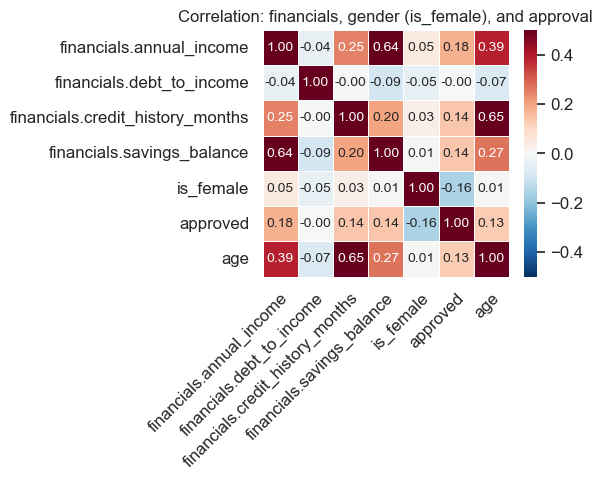

Variables correlating with both is_female and approved may act as proxies for gender.


In [16]:
# Correlation heatmap: financials, gender, approval (cleaner style)
lr_df = df[df[gender_col].isin(["Male", "Female"])].copy()
lr_df["is_female"] = (lr_df[gender_col] == "Female").astype(int)
lr_df["approved"] = lr_df[outcome_col].astype(int)
num_cols = ["financials.annual_income", "financials.debt_to_income", "financials.credit_history_months", "financials.savings_balance", "is_female", "approved"]
if "age" not in lr_df.columns:
    ref_date = pd.Timestamp("2024-01-01")
    lr_df["age"] = ((ref_date - pd.to_datetime(lr_df["applicant_info.date_of_birth"])).dt.days / 365.25).astype(float)
num_cols = [c for c in num_cols if c in lr_df.columns] + (["age"] if "age" in lr_df.columns else [])
heatmap_df = lr_df[num_cols].dropna(how="all")
corr = heatmap_df.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5, annot_kws={"size": 10})
ax.set_title("Correlation: financials, gender (is_female), and approval", fontsize=12, fontweight="medium")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()
print("Variables correlating with both is_female and approved may act as proxies for gender.")


Female mean rate : 4.488  (n=127)
Male mean rate   : 4.628  (n=163)


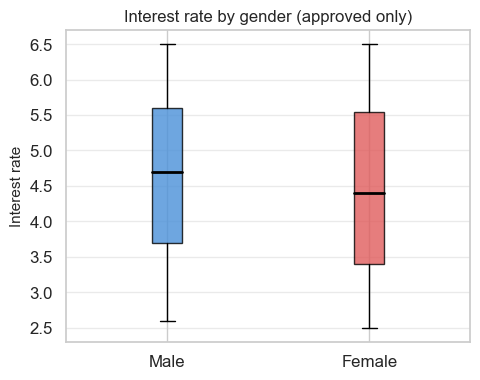

In [17]:
# Interest rate by gender (approved applicants only)
rate_col = "decision.interest_rate"
approved = df[df[outcome_col] == True].copy()
approved = approved[approved[gender_col].isin(["Male", "Female"])].dropna(subset=[rate_col])
f_rates = approved.loc[approved[gender_col] == "Female", rate_col]
m_rates = approved.loc[approved[gender_col] == "Male", rate_col]
print(f"Female mean rate : {round(f_rates.mean(), 3)}  (n={len(f_rates)})")
print(f"Male mean rate   : {round(m_rates.mean(), 3)}  (n={len(m_rates)})")
fig, ax = plt.subplots(figsize=(5, 4))
bp = ax.boxplot([m_rates, f_rates], labels=["Male", "Female"], patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(COLOUR_M if i == 0 else COLOUR_F)
    patch.set_alpha(0.8)
for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(2)
ax.set_title("Interest rate by gender (approved only)", fontsize=12, fontweight="medium")
ax.set_ylabel("Interest rate", fontsize=11)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


**Interpretation (4.2)**  
**DTI:** Mean DTI is similar for males (0.25) and females (0.24), yet approval rates differ (66% vs 51%), suggesting the model may use the same input differently by group. **Income:** Correlation with approval is higher for females (r = 0.24) than for males (r = 0.13). **Rejection reasons:** The distribution does not differ significantly by gender (chi-square p ≈ 0.47). The **heatmap** shows which financial variables (and age) correlate with both gender and approval; credit history and income are potential proxies and should be monitored. We do not classify income or credit history as proxy discriminators here because they are legitimate risk factors; the two-condition proxy test is applied to ZIP and spending, where the proxy concern is clearer. **Interest rates** for approved applicants show similar mean rates by gender (T-test p ≈ 0.31), so no significant pricing disparity is detected. We do not run a full two-condition proxy test here because DTI, income, and credit history are legitimate risk factors; Section 6 tests whether they explain the gender gap. These variables are controlled for in the conditional fairness model (Section 6).


<a id='4-3-spending'></a>

### 4.3 Spending Behaviour

We test whether **flagged spending** (Gambling, Alcohol, Adult Entertainment) acts as a proxy for gender. **Condition 1:** Flagged spending must be associated with gender (chi-square). **Condition 2:** Flagged spending must predict approval after controlling for gender and financial risk (logistic regression). We first parse spending and show which categories differ by gender; then we build a binary *spend_flagged* and run the two-condition test.


In [18]:
spend_col = "spending_behavior"
def parse_spend(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except Exception:
        return []
rows = []
for _, r in df[["_id", spend_col]].iterrows():
    items = parse_spend(r[spend_col])
    for it in items:
        rows.append({"_id": r["_id"], "category": it.get("category"), "amount": float(it.get("amount", 0))})
spend_long = pd.DataFrame(rows)
spend_wide = spend_long.pivot_table(index="_id", columns="category", values="amount", aggfunc="sum", fill_value=0)
spend_wide["total_spend"] = spend_wide.sum(axis=1)
df_sp = df.merge(spend_wide.reset_index(), on="_id", how="left").fillna(0)
df_sp = df_sp[df_sp[gender_col].isin(["Male", "Female"])].copy()
df_sp["is_female"] = (df_sp[gender_col] == "Female").astype(int)
results = []
for feat in spend_wide.columns:
    f = df_sp.loc[df_sp["is_female"] == 1, feat]
    m = df_sp.loc[df_sp["is_female"] == 0, feat]
    p_gender = stats.mannwhitneyu(f, m, alternative="two-sided").pvalue
    results.append([feat, f.mean(), m.mean(), p_gender])
proxy_spend = pd.DataFrame(results, columns=["feature", "mean_female", "mean_male", "p_gender_diff"]).sort_values("p_gender_diff")
display(proxy_spend.head(10))
print("\nLow p-values indicate spending categories that differ by gender and could act as proxy variables.")

# Build flagged spending (Gambling, Alcohol, Adult Entertainment)
flagged_cats = [c for c in ["Gambling", "Alcohol", "Adult Entertainment"] if c in df_sp.columns]
df_sp["spend_flagged"] = (df_sp[flagged_cats].sum(axis=1) > 0).astype(int)

# Two-condition proxy test: Spending
from scipy.stats import chi2_contingency
ct_spend_gender = pd.crosstab(df_sp["spend_flagged"], df_sp[gender_col], rownames=["Flagged spending"], colnames=["Gender"])
if ct_spend_gender.values.min() >= 5:
    chi2_sg, p_sg, _, _ = chi2_contingency(ct_spend_gender)
    print("\nCondition 1: Flagged spending vs Gender:")
    print(ct_spend_gender.to_string())
    print(f"  χ² = {chi2_sg:.4f}, p = {p_sg:.4f}")
    print(f"  Condition 1 met: {'YES' if p_sg < 0.05 else 'NO'}")
else:
    print("\nCondition 1: expected cell counts < 5; chi-square result unreliable.")
    p_sg = 1.0

# Condition 2: flagged spending → approval after controls
if "age" not in df_sp.columns:
    ref_date = pd.Timestamp("2024-01-01")
    df_sp["age"] = ((ref_date - pd.to_datetime(df_sp["applicant_info.date_of_birth"])).dt.days / 365.25).astype(float)
inc_col = "financials.annual_income"
dti_col = "financials.debt_to_income"
hist_col = "financials.credit_history_months"
sav_col = "financials.savings_balance"
df_sp["gender_bin"] = (df_sp[gender_col] == "Male").astype(int)
df_sp["approved"] = df_sp[outcome_col].astype(int)
feat_sp = ["gender_bin", "age", inc_col, dti_col, hist_col, sav_col, "spend_flagged"]
df_sp_cln = df_sp[feat_sp + ["approved"]].dropna()
Xs = sm.add_constant(df_sp_cln[feat_sp])
ys = df_sp_cln["approved"]
logit_s = sm.Logit(ys, Xs).fit(disp=0)
coef_sp = logit_s.params["spend_flagged"]
p_sp = logit_s.pvalues["spend_flagged"]
print("\nCondition 2: Flagged spending effect on approval (controlling for gender + financial risk):")
print(f"  spend_flagged coefficient: {coef_sp:.4f}")
print(f"  Odds ratio:                {np.exp(coef_sp):.4f}")
print(f"  p-value:                   {p_sp:.4f}")
print(f"  Condition 2 met: {'YES' if p_sp < 0.05 else 'NO'}")
both_sp = p_sg < 0.05 and p_sp < 0.05
print(f"\nPROXY VERDICT (Spending): {'Both conditions met: proxy risk confirmed' if both_sp else 'Not fully established'}")


,feature,mean_female,mean_male,p_gender_diff
6,Gambling,9.796,0.000000,0.014668
11,Shopping,35.692,63.414634,0.048293
1,Alcohol,7.736,13.471545,0.126854
7,Groceries,51.888,72.048780,0.127411
9,Insurance,55.104,74.174797,0.142085
0,Adult Entertainment,1.288,10.707317,0.170483
3,Education,75.108,53.662602,0.197888
15,total_spend,763.736,817.894309,0.301790
4,Entertainment,77.752,60.686992,0.447719
8,Healthcare,67.020,56.658537,0.479331



Low p-values indicate spending categories that differ by gender and could act as proxy variables.

Condition 1: Flagged spending vs Gender:
Gender            Female  Male
Flagged spending              
0                    240   234
1                     10    12
  χ² = 0.0659, p = 0.7973
  Condition 1 met: NO

Condition 2: Flagged spending effect on approval (controlling for gender + financial risk):
  spend_flagged coefficient: 0.2320
  Odds ratio:                1.2611
  p-value:                   0.6213
  Condition 2 met: NO

PROXY VERDICT (Spending): Not fully established


**Interpretation (4.3)**  
**Flagged spending** = any spending in Gambling, Alcohol, or Adult Entertainment. **Condition 1** (flagged ↔ gender): A significant chi-square means these categories are associated with gender. **Condition 2** (flagged → approval after controls): A significant coefficient for *spend_flagged* means they predict approval even after controlling for gender and financial risk. If **both** conditions are met, the verdict is **proxy risk confirmed**: consider excluding or constraining these spending categories in the model. If the verdict is *Not fully established*, there is insufficient evidence for proxy discrimination via flagged spending in this sample (e.g. small cell counts in Condition 1 or no independent predictive power in Condition 2).


<a id='5-interaction-effects'></a>

## 5. Interaction effects between attributes

Does the gender gap in approval vary by age, income, or region? Below: gender × age, gender × income, gender × zip/region.

<a id='5-1-gender-age'></a>

### 5.1 Gender × age

Approval rate by both gender and age group. Large differences within an age band suggest interaction effects.

The table and heatmap below show approval rate by gender and age group. Large differences within an age band (e.g. young women vs young men) indicate interaction effects.

approval_rate         count     
applicant_info.gender        Female   Male Female Male
age_group                                             
18-30                         0.311  0.527     61   55
31-40                         0.580  0.667     81   87
41-50                         0.600  0.769     60   65
51-65                         0.511  0.639     45   36
65+                           1.000  1.000      1    2

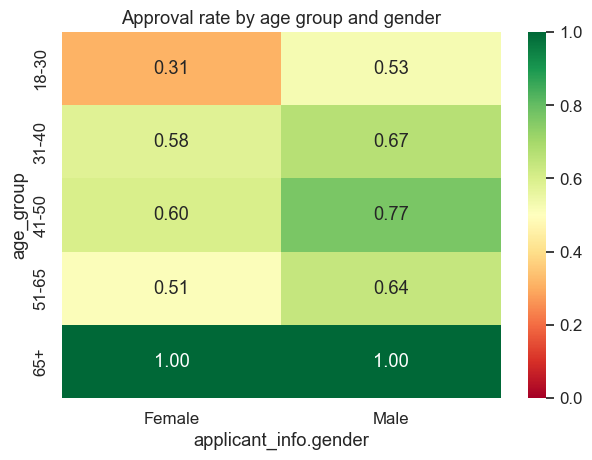

In [19]:
# Approval rate by gender and age group
age_valid_g = age_valid[age_valid[gender_col].isin(["Male", "Female"])]
by_gender_age = age_valid_g.groupby([gender_col, "age_group"])[outcome_col].agg(["mean", "count"]).round(3)
by_gender_age.columns = ["approval_rate", "count"]
display(by_gender_age.unstack(level=0))
# Pivot for a heatmap
pivot = age_valid_g.pivot_table(values=outcome_col, index="age_group", columns=gender_col, aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Approval rate by age group and gender")
plt.tight_layout()
plt.show()

**Segment-specific disparate impact (18–30).** To quantify the interaction in one number: compute the disparate impact ratio *within* the 18–30 age band. If DI &lt; 0.8 here, young women are disproportionately affected even after conditioning on age.

In [20]:
# Disparate impact within 18–30 age band only
young = age_valid_g[age_valid_g["age_group"] == "18-30"]
if len(young) >= 10:
    rates_18_30 = young.groupby(gender_col)[outcome_col].mean()
    r_m = rates_18_30.get("Male", 0)
    r_f = rates_18_30.get("Female", 0)
    di_18_30 = r_f / r_m if r_m > 0 else float("nan")
    n_m = (young[gender_col] == "Male").sum()
    n_f = (young[gender_col] == "Female").sum()
    print(f"Age 18–30 only: Female approval {r_f:.2%} (n={n_f}), Male {r_m:.2%} (n={n_m})")
    print(f"Segment DI (18–30): {di_18_30:.3f} - {'Below ' + str(DI_THRESHOLD) + ': disparate impact in this segment' if di_18_30 < DI_THRESHOLD else 'At or above ' + str(DI_THRESHOLD)}")
else:
    print("Insufficient data in 18–30 for segment DI.")

Age 18–30 only: Female approval 31.15% (n=61), Male 52.73% (n=55)
Segment DI (18–30): 0.591 - Below 0.8: disparate impact in this segment


**Test for significant interaction (5.1).** We test whether approval is associated with the (gender × age_group) combination using a chi-square test on the contingency table. If significant, the pattern of approval across gender and age is not due to chance.

In [21]:
# Test whether (gender × age_group) is associated with approval (chi-square)
from scipy.stats import chi2_contingency
df_ia = age_valid_g.dropna(subset=["age_group"]).copy()
df_ia["approved"] = df_ia[outcome_col].astype(int)
# Drop tiny groups that cause separation (e.g. 65+ has 3 people)
min_cell = 5
age_counts = df_ia.groupby("age_group").size()
keep_ages = age_counts[age_counts >= min_cell].index.tolist()
df_ia = df_ia[df_ia["age_group"].isin(keep_ages)]
if len(keep_ages) >= 2:
    df_ia["gender_age"] = df_ia[gender_col].astype(str) + " · " + df_ia["age_group"].astype(str)
    ct = pd.crosstab(df_ia["gender_age"], df_ia["approved"])
    chi2_val, p_val, dof, _ = chi2_contingency(ct)
    print("Gender × age_group vs approval (chi-square):")
    print(f"  χ² = {chi2_val:.3f},  df = {dof},  p = {p_val:.4f}")
    print(f"  Association significant: {'YES' if p_val < 0.05 else 'NO'}")
else:
    print("Gender × age_group: Too few age groups with n≥5; test skipped.")

Gender × age_group vs approval (chi-square):
  χ² = 32.438,  df = 7,  p = 0.0000
  Association significant: YES


**Interpretation (5.1)**  
Female approval is lower than male in every age band; the gap is largest for 18–30 (about 31% vs 53%), with segment DI 0.59 in that band (below the 0.8 threshold). The chi-square test (below) is significant (p ≈ 0.0000), so the association between (gender × age_group) and approval is not due to chance. The combination of gender and age indicates that young women are particularly affected; the team should prioritize the 18–30 segment for fairness review and consider segment-specific analyses or mitigations.

<a id='5-2-gender-income'></a>

### 5.2 Gender × income

Approval rate by gender **within income bands** (e.g. tertiles or quartiles). If the gender gap is similar across income levels, the disparity is not simply explained by income; if it varies, income may interact with gender.

approval_rate         count     
applicant_info.gender        Female   Male Female Male
income_tertile                                        
Low                           0.361  0.547     83   86
Medium                        0.551  0.741     78   85
High                          0.607  0.707     89   75

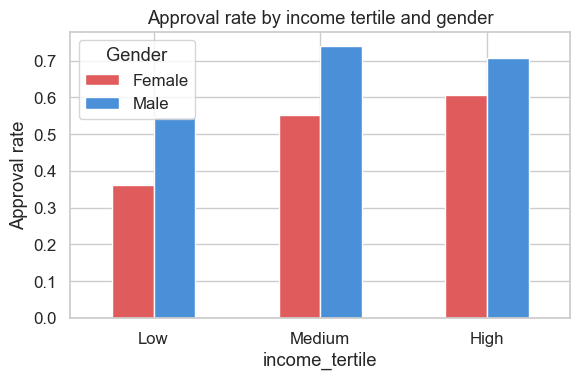


If the gender gap persists across income bands, disparity is not fully explained by income.


In [22]:
# Approval rate by gender within income bands (tertiles)
inc_col = "financials.annual_income"
income_valid = df[df[gender_col].isin(["Male", "Female"])].copy()
income_valid = income_valid.dropna(subset=[inc_col, outcome_col])
income_valid["income_tertile"] = pd.qcut(income_valid[inc_col], q=3, labels=["Low", "Medium", "High"], duplicates="drop")
by_gender_income = income_valid.groupby(["income_tertile", gender_col])[outcome_col].agg(["mean", "count"]).round(3)
by_gender_income.columns = ["approval_rate", "count"]
display(by_gender_income.unstack(level=1))
# Grouped bar chart: approval rate by income tertile and gender
pivot_inc = income_valid.pivot_table(values=outcome_col, index="income_tertile", columns=gender_col, aggfunc="mean")
pivot_inc.plot(kind="bar", figsize=(6, 4), color=[COLOUR_F, COLOUR_M], legend=True)
plt.title("Approval rate by income tertile and gender")
plt.ylabel("Approval rate")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()
print("\nIf the gender gap persists across income bands, disparity is not fully explained by income.")

**Test for significant interaction (5.2).** We test whether approval is associated with the (gender × income_tertile) combination using a chi-square test on the contingency table. If significant, the pattern of approval across gender and income band is not due to chance.

In [23]:
# Test whether (gender × income_tertile) is associated with approval (chi-square)
from scipy.stats import chi2_contingency
df_i = income_valid.dropna(subset=["income_tertile"]).copy()
df_i["approved"] = df_i[outcome_col].astype(int)
df_i["segment"] = df_i[gender_col].astype(str) + " · " + df_i["income_tertile"].astype(str)
ct_inc = pd.crosstab(df_i["segment"], df_i["approved"])
if ct_inc.values.min() >= 5:
    chi2_inc, p_inc, dof_inc, _ = chi2_contingency(ct_inc)
    print("Gender × income_tertile vs approval (chi-square):")
    print(f"  χ² = {chi2_inc:.3f},  df = {dof_inc},  p = {p_inc:.4f}")
    print(f"  Association significant: {'YES' if p_inc < 0.05 else 'NO'}")
else:
    print("Gender × income_tertile: Some cells have <5 observations; test skipped.")

Gender × income_tertile vs approval (chi-square):
  χ² = 31.255,  df = 5,  p = 0.0000
  Association significant: YES


**Interpretation (5.2)**  
Female approval is lower than male in every income tertile (Low: ~36% vs 55%; Medium: ~55% vs 74%; High: ~61% vs 71%). The chi-square test (below) is significant (p ≈ 0.0000), so the pattern of approval across gender and income band is not due to chance. Because the gender gap persists across income bands, the disparity is not fully explained by income. The team should consider segment-specific fairness monitoring by income band and ensure that the model does not disproportionately disadvantage women within any income tier.

<a id='5-3-gender-zip'></a>

### 5.3 Gender × zip/region

Approval rate by gender **within each region** (zip prefix). Shows whether the gender disparity holds within regions or only across them (geography as potential confound).

applicant_info.gender,Female,Male
zip_prefix,,
100,0.464,0.67
300,0.500,0.60
902,0.514,0.60


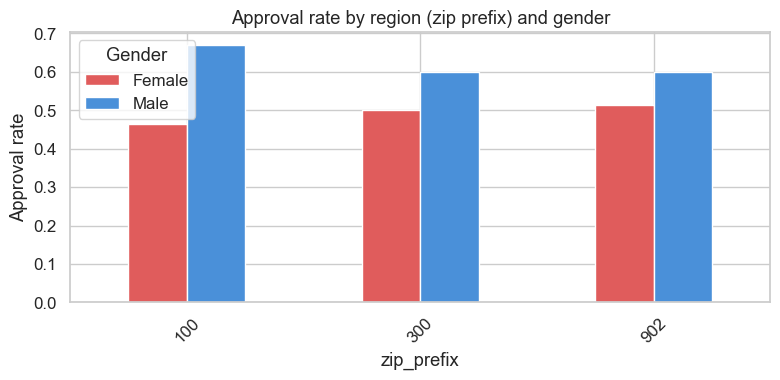

In [24]:
# Approval by gender within each region (zip prefix)
zip_col = "applicant_info.zip_code"
df_zip_g = df[df[zip_col].notna() & df[gender_col].isin(["Male", "Female"])].copy()
df_zip_g["zip_prefix"] = df_zip_g[zip_col].astype(int).astype(str).str[:3]
by_region_gender = df_zip_g.groupby(["zip_prefix", gender_col])[outcome_col].agg(["mean", "count"]).round(3)
by_region_gender.columns = ["approval_rate", "count"]
# Pivot: rows = region, columns = gender (only regions with at least 5 per group for stability)
region_counts = df_zip_g.groupby(["zip_prefix", gender_col]).size().unstack(fill_value=0)
valid_regions = (region_counts >= 5).all(axis=1)
valid_regions = valid_regions[valid_regions].index.tolist()
if valid_regions:
    pivot_region = df_zip_g[df_zip_g["zip_prefix"].isin(valid_regions)].pivot_table(
        values=outcome_col, index="zip_prefix", columns=gender_col, aggfunc="mean"
    )
    display(pivot_region.round(3))
    pivot_region.plot(kind="bar", figsize=(8, 4), color=[COLOUR_F, COLOUR_M], legend=True)
    plt.title("Approval rate by region (zip prefix) and gender")
    plt.ylabel("Approval rate")
    plt.xticks(rotation=45)
    plt.legend(title="Gender")
    plt.tight_layout()
    plt.show()
else:
    display(by_region_gender.head(15))
    print("Regions with ≥5 applicants per gender: none; table above shows raw breakdown.")

**Interpretation (5.3)**  
Within each region (zip prefix) with sufficient data, female approval remains below male (e.g. region 100: ~46% vs 67%; 300 and 902 show a similar pattern). 

<a id='6-fairness'></a>

## 6. Fairness (beyond raw disparity)

Conditional fairness (does the gap hold after controlling for risk?), interest rate/pricing by gender, and optional fairness metrics.

<a id='6-1-conditional-fairness'></a>

### 6.1 Conditional Fairness

Disparate impact shows overall outcome differences by gender.  
To go further, this section tests whether **gender remains associated with loan approval after controlling for financial risk variables** such as income, debt-to-income ratio, credit history, savings, and age.

If gender is still statistically significant after these controls, this suggests **conditional unfairness** rather than only raw outcome disparity.

In [25]:
# Logistic regression: approval ~ risk factors + gender

inc_col = "financials.annual_income"
dti_col = "financials.debt_to_income"
hist_col = "financials.credit_history_months"
sav_col = "financials.savings_balance"

df_lr = df[df[gender_col].isin(["Male", "Female"])].copy()
df_lr["is_female"] = (df_lr[gender_col] == "Female").astype(int)
df_lr["y"] = df_lr[outcome_col].astype(int)

# age is created in Section 3 (Age-based patterns)
assert "age" in df_lr.columns, "Run Section 3 (Age-based patterns) first so the age column is created."

features = ["is_female", inc_col, dti_col, hist_col, sav_col, "age"]
model_data = df_lr[features + ["y"]].dropna()

X = sm.add_constant(model_data[features])
y = model_data["y"]

logit = sm.Logit(y, X).fit(disp=False)
print(logit.summary())

coef = logit.params["is_female"]
pval = logit.pvalues["is_female"]
odds_ratio = float(np.exp(coef))

print("\nGender (Female=1) effect AFTER controls:")
print(f"  coef = {coef:.4f}")
print(f"  odds ratio = {odds_ratio:.3f}")
print(f"  p-value = {float(pval):.5f}")

# Controlled prediction gap: flip only gender, keep all other features fixed
tmp = model_data[features].copy()
tmp_male = tmp.copy()
tmp_male["is_female"] = 0

tmp_fem = tmp.copy()
tmp_fem["is_female"] = 1

tmp_male = sm.add_constant(tmp_male, has_constant="add")
tmp_fem = sm.add_constant(tmp_fem, has_constant="add")

# Force same column order as training matrix
tmp_male = tmp_male[X.columns]
tmp_fem = tmp_fem[X.columns]

# Controlled prediction gap: mean predicted approval if all were Male vs all Female (other features held constant)
p_male = logit.predict(tmp_male).mean()
p_fem = logit.predict(tmp_fem).mean()

print(f"\nMean predicted approval if Male (holding others constant):   {p_male:.3f}")
print(f"Mean predicted approval if Female (holding others constant): {p_fem:.3f}")
print(f"Controlled gap (Female - Male): {p_fem - p_male:.3f}")

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  489
Model:                          Logit   Df Residuals:                      482
Method:                           MLE   Df Model:                            6
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                 0.05345
Time:                        03:59:19   Log-Likelihood:                -314.45
converged:                       True   LL-Null:                       -332.21
Covariance Type:            nonrobust   LLR p-value:                 3.432e-06
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.5867      0.468     -1.254      0.210      -1.504       0.331
is_female                           -0.7176      0.192     -3.728

**Interpretation (6.1)**  
Gender remains **statistically significant** after controlling for income, DTI, credit history, savings, and age (p ≈ 0.0002). The odds ratio for female (vs male) is about 0.49, i.e. lower odds of approval for women at the same risk profile. The controlled prediction gap (female − male mean predicted approval, holding other features constant) is about −0.16. This indicates **conditional unfairness**: the approval gap is not fully explained by the financial and risk variables we controlled for. From a governance perspective, the model or process may be using gender (or a proxy) in a way that warrants bias audits, fairness constraints, or removal of protected attributes from the decision pipeline.

<a id='6-2-interest-rate-pricing'></a>

### 6.2 Interest Rate / Pricing Fairness

Approval bias is not the only fairness concern in lending.  
Even among approved applicants, institutions may still treat groups differently through **pricing**, such as assigning systematically different interest rates.

This section compares the distribution of **interest rates by gender among approved applications**.

Female mean rate : 4.488  (n=127)
Male mean rate   : 4.628  (n=163)
Two-sample t-test (Female vs Male): p = 0.3104


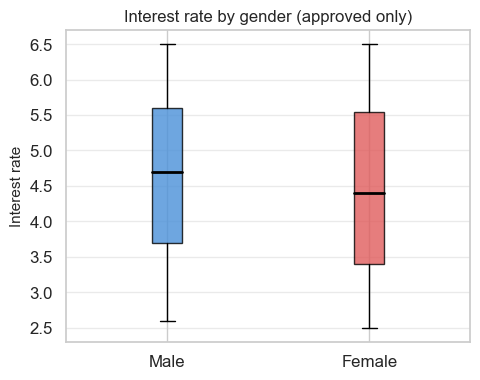

In [26]:
# Interest rate by gender (approved applicants only)
rate_col = "decision.interest_rate"
approved = df[df[outcome_col] == True].copy()
approved = approved[approved[gender_col].isin(["Male", "Female"])].dropna(subset=[rate_col])
f_rates = approved.loc[approved[gender_col] == "Female", rate_col]
m_rates = approved.loc[approved[gender_col] == "Male", rate_col]

print(f"Female mean rate : {f_rates.mean():.3f}  (n={len(f_rates)})")
print(f"Male mean rate   : {m_rates.mean():.3f}  (n={len(m_rates)})")
t_stat, p_ttest = stats.ttest_ind(f_rates, m_rates)
print(f"Two-sample t-test (Female vs Male): p = {p_ttest:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
bp = ax.boxplot([m_rates, f_rates], labels=["Male", "Female"], patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(COLOUR_M if i == 0 else COLOUR_F)
    patch.set_alpha(0.8)
for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(2)
ax.set_title("Interest rate by gender (approved only)", fontsize=12, fontweight="medium")
ax.set_ylabel("Interest rate", fontsize=11)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretation (6.2)**  
Among approved applicants, mean interest rates by gender are similar, and the two-sample t-test does not show a statistically significant difference (p ≈ 0.31). So we do **not** find evidence of systematic pricing disparity by gender in this dataset. Fairness risk from interest-rate discrimination is therefore **low**; the main concerns remain approval-stage disparity (Section 2) and conditional unfairness (Section 6.1). Governance should still include pricing transparency and periodic re-checks as new data arrives.

<a id='6-3-fairness-metrics'></a>

### 6.3 Fairness Metrics

We use **fairlearn** to report the **demographic parity difference**: the gap between the highest and lowest group-level approval rate (here, by gender). A value of 0 means parity; larger values indicate greater disparity.

In [27]:
# Demographic parity difference (fairlearn definition: max - min group approval rate; 0 = parity)
fair_valid = df[df[gender_col].isin(["Male", "Female"])][[gender_col, outcome_col]].dropna()
y_true = fair_valid[outcome_col].astype(int)
sensitive = (fair_valid[gender_col] == "Female").astype(int)

try:
    from fairlearn.metrics import demographic_parity_difference
    dp_diff = demographic_parity_difference(y_true, y_true, sensitive_features=sensitive)
except ImportError:
    rate_male = fair_valid.loc[fair_valid[gender_col] == "Male", outcome_col].astype(int).mean()
    rate_female = fair_valid.loc[fair_valid[gender_col] == "Female", outcome_col].astype(int).mean()
    dp_diff = abs(rate_male - rate_female)
    print("(Computed without fairlearn - install fairlearn for the library metric.)\n")

rate_female = fair_valid.loc[fair_valid[gender_col] == "Female", outcome_col].astype(int).mean()
rate_male = fair_valid.loc[fair_valid[gender_col] == "Male", outcome_col].astype(int).mean()
print(f"Demographic parity difference (approval by gender): {dp_diff:.4f}")
print("(0 = parity; value = gap between highest and lowest group approval rate)")
print(f"\nApproval rates: Female {rate_female:.2%}, Male {rate_male:.2%}")

(Computed without fairlearn - install fairlearn for the library metric.)

Demographic parity difference (approval by gender): 0.1546
(0 = parity; value = gap between highest and lowest group approval rate)

Approval rates: Female 50.80%, Male 66.26%


**Interpretation (6.3)**  
The **demographic parity difference** (max minus min approval rate by gender) is about 0.15 (15 percentage points), with male approval higher than female. This matches the disparate impact story in Section 2: the same gap expressed as a single fairness metric. A value of 0 would indicate parity; 0.15 indicates material disparity. This metric is useful for monitoring over time and for aligning with frameworks (e.g. fairlearn) that use demographic parity. It does not account for legitimate risk differences; hence the importance of Section 6.1 (conditional fairness), which shows that the gap persists after controlling for risk.

<a id='7-synthesis'></a>

## 7. Synthesis

Risk matrix and summary with governance recommendations.

<a id='7-1-risk-matrix'></a>

### 7.1 Bias Risk Matrix

The table below summarizes the key bias risks identified in the analysis. Each row states the protected attribute (or proxy) analyzed, the evidence from the notebook, risk level, and governance implications.

| Risk Area | Evidence | Risk Level | Why it matters | Recommended Controls |
|-----------|----------|------------|----------------|----------------------|
| **Gender disparate impact (approvals)** | Female 50.8%, Male 66.3%; DI ratio 0.77 (<0.8); chi-square p≈0.0007; demographic parity difference 0.15 | **High** | Four-fifths rule suggests potential discrimination when DI < 0.8; parity gap material for monitoring | Fairness monitoring (DI and demographic parity); periodic bias audits; human review for borderline applications |
| **Conditional fairness (gender after controls)** | Gender significant after controlling for income, DTI, credit history, savings, age: OR≈0.49, p<0.001; controlled approval gap ≈−0.16 | **High** | Gap not explained by risk factors; model or process may use gender or a proxy | Remove or constrain protected attributes in models; fairness constraints; model governance review |
| **Interest rate (approved applicants)** | No significant difference by gender (t-test p≈0.31); mean rates similar by group | **Low** | Systematic pricing differences could indicate discrimination; current data shows no evidence | Pricing transparency; periodic re-check of interest rates by gender |
| **Age-based patterns** | Lowest approval in 18–30 (41.4%); approval varies by age group; chi-square indicates association between age group and approval | **Moderate** | Unjustified age cutoffs or indirect age effects could create fairness risk | Monitor approval rates by age band; avoid unjustified age-based cutoffs; review for indirect age effects |
| **Proxy variables (ZIP/region, flagged spending)** | **ZIP:** Two-condition test: C1 met (ZIP↔gender), C2 not met (ZIP→approval after controls). Verdict: not fully established. **Spending:** C1/C2 not met; verdict not fully established; spending patterns differ by gender | **Low–Moderate** | Proxies can indirectly encode protected attributes; heatmap flags income, credit history | Proxy detection testing; avoid unnecessary use of region; constrain flagged spending if used; feature review and responsible data collection |
| **Interaction effects (gender × age, × income, × region)** | Segment DI for 18–30 ≈0.59 (below 0.8); young women most disadvantaged; chi-square significant for gender×age (p≈0.0000) and gender×income; region limited by small cells | **High** | Disparity varies by segment; "one size fits all" may disadvantage subgroups (especially young women) | Segment-specific fairness monitoring (especially 18–30); review model by income band and region; consider segment-level policies |


<a id='7-2-types-of-bias'></a>

### 7.2 Types of Bias in the Credit Dataset

Mapping the findings to the **five types of bias** used in data governance (Session 5 framework):

| Type | Relevance to this dataset |
|------|----------------------------|
| **Historical** | The observed female–male approval gap (DI ≈ 0.77, Female 50.8% vs Male 66.3%) is consistent with historical bias in the underlying process. Training or calibrating models on this data without remediation may perpetuate that pattern. |
| **Measurement** | ZIP/region, income, credit history, and spending behaviour can act as **proxies** for protected characteristics. The heatmap (gender–approval–financial correlations), region-level patterns, and spending-by-gender tests support that non-protected variables may indirectly encode protected ones; two-condition proxy tests (ZIP, flagged spending) did not fully establish proxy discrimination in this sample. |
| **Aggregation** | A single approval process is applied across groups. Interaction effects show that outcomes differ by segment: young women (18–30) have the lowest segment DI (≈ 0.59). "One size fits all" may disadvantage this subgroup. |
| **Selection** | The analysis does not assess whether the applicant pool is representative of the target population. Selection bias (e.g. by geography or channel) could affect fairness conclusions. |
| **Feedback loop** | If approval outcomes feed back into training or calibration, lower approval rates for one group reduce data from that group and can reinforce worse outcomes over time. NovaCred should assess whether its pipeline creates such a loop. |

<a id='7-3-summary'></a>

### 7.3 Bias Summary and Governance Recommendations

**Bias summary**

The analysis identifies **material gender-related disparities in credit approval** that create fairness risk in lending decisions. Female applicants have a substantially lower approval rate (50.8%) than male applicants (66.3%), yielding a disparate impact ratio of **0.77**, below the four-fifths rule threshold of 0.8. This association is statistically significant (chi-square p ≈ 0.0007), and the demographic parity difference (0.15) quantifies the same gap for monitoring. **Conditional fairness** analysis shows that the gap is not explained by the financial and risk variables we controlled for: gender remains a significant predictor of approval after controlling for income, DTI, credit history, savings, and age (odds ratio ≈ 0.49, p &lt; 0.001), with a controlled approval gap of about −0.16. This points to **conditional unfairness**, i.e. the process or model may be using gender or a close proxy in a way that is not justified by risk.

**Segment-level analysis** reinforces that **young women (18–30)** are the most affected subgroup: segment-level disparate impact in that band is approximately **0.59**, well below 0.8, and the interaction between gender and age is highly significant (chi-square p ≈ 0.0000). Disparities also vary by income tertile and region (gender × income significant; region limited by sample size). By contrast, **interest rate** assignment among approved applicants does not show a significant difference by gender (t-test p ≈ 0.31), so pricing fairness risk is currently low. **Proxy tests** (ZIP/region and flagged spending) did not fully establish proxy discrimination in this sample (two-condition verdicts: not fully established), but financial and behavioural variables (income, credit history, spending patterns) remain potential proxies and should be monitored.

In summary, the main fairness risks are: **(1)** overall and segment-specific gender disparity in approval outcomes, **(2)** conditional unfairness after controlling for risk, and **(3)** the possibility that a single model applied across segments disadvantages young women. These findings should inform governance, model design, and ongoing monitoring.

**Bias governance recommendations**

- **Fairness monitoring:** Track disparate impact ratio and demographic parity difference by gender (and, where sample size allows, by age band and segment) on a defined schedule (e.g. quarterly); set alert thresholds (e.g. DI &lt; 0.8) and escalate when breached.
- **Periodic disparate impact testing:** Run formal DI and four-fifths rule assessments whenever the model, population, or policy changes; document results and any remediation.
- **Conditional fairness and model governance:** Ensure protected attributes are not used as direct model inputs; consider fairness constraints or parity-based objectives in model development; conduct regular model governance reviews to confirm that gender (or proxies) do not drive approval beyond risk.
- **Segment-specific review:** Prioritise the 18–30 segment (and, if applicable, low-income or specific regions) for fairness review; assess whether segment-specific policies or separate monitoring are needed.
- **Proxy variable audits:** Periodically re-run proxy detection (e.g. two-condition tests) on ZIP/region, spending, and financial variables; maintain a feature inventory with proxy risk ratings; avoid or constrain variables that encode protected characteristics without clear business justification.
- **Human oversight:** Retain human review for borderline or high-stakes applications where automated decisions are close to the decision boundary; use this to detect and correct potential bias.
- **Data and feedback loop:** Before using approval or outcome data for training or recalibration, assess suitability (e.g. representativeness, historical bias); put in place controls to avoid feedback loops that reinforce lower approval rates for already disadvantaged groups.
- **Pricing transparency:** Continue to monitor interest rates (and other pricing) by protected attributes; document and periodically re-check for discriminatory pricing even when current tests show no significant disparity.